# 在多分类任务实验中使用早停机制
这里采用实验三的手动Adam优化算法

韩佳轩，23281106，计算机科学与技术学院

In [1]:
# 导入所需的包

import torch
import torchvision
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

In [2]:
# 设置随机种子以确保结果可复现
torch.manual_seed(23281106)
np.random.seed(23281106)

## MNIST数据集下载与读取

In [3]:
train_dataset = torchvision.datasets.MNIST(root='./Datasets/MNIST',
                                           train=True,
                                           transform=torchvision.transforms.ToTensor(),
                                           download=True)
test_dataset = torchvision.datasets.MNIST(root='./Datasets/MNIST',
                                          train=False,
                                            transform=torchvision.transforms.ToTensor())

In [4]:
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=32,
                                           shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset,
                                            batch_size=32,
                                            shuffle=False)

In [5]:
# 划分训练数据
# 训练集:验证集=8:2
num_train = int(len(train_dataset) * 0.8)
num_val = len(train_dataset) - num_train

train_dataset, val_dataset = torch.utils.data.random_split(train_dataset, [num_train, num_val])
train_loader = torch.utils.data.DataLoader(dataset=train_dataset,
                                           batch_size=32,
                                           shuffle=True)
val_loader = torch.utils.data.DataLoader(dataset=val_dataset,
                                         batch_size=32,
                                         shuffle=False)
            

print(f'训练集大小: {len(train_dataset)}')
print(f'验证集大小: {len(val_dataset)}')

训练集大小: 48000
验证集大小: 12000


In [6]:
for X, y in train_loader:
    print("Shape of X: ", X.shape)
    print("Shape of y: ", y.shape)
    break

Shape of X:  torch.Size([32, 1, 28, 28])
Shape of y:  torch.Size([32])


## 实现前馈神经网络

### 1. 手动实现前馈神经网络

In [7]:
# 1. 手动实现前馈神经网络
class ManualNet(nn.Module):
    def __init__(self):
        super(ManualNet, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(784, 256),
            nn.ReLU(),
            nn.Linear(256, 256),
            nn.ReLU(),
            nn.Linear(256, 10)
        )
    
    def forward(self, x):
        return self.network(x)

## 手动实现Adam优化算法

In [8]:
def init_adam_states(params):
    v_w1, v_b1, v_w2, v_b2, v_w3, v_b3 = (torch.zeros_like(param) for param in params)
    s_w1, s_b1, s_w2, s_b2, s_w3, s_b3 = (torch.zeros_like(param) for param in params)
    return ((v_w1, s_w1), (v_b1, s_b1), (v_w2, s_w2), (v_b2, s_b2), (v_w3, s_w3), (v_b3, s_b3))

def adam(params, states, lr, t):
    beta1, beta2, eps = 0.9, 0.999, 1e-6
    for p, (v, s) in zip(params, states):
        with torch.no_grad():
            v[:] = beta1 * v + (1 - beta1) * p.grad
            s[:] = beta2 * s + (1 - beta2) * (p.grad ** 2)

            v_corrected = v / (1 - beta1 ** t)
            s_corrected = s / (1 - beta2 ** t)

            p[:] = p - lr * v_corrected / (torch.sqrt(s_corrected) + eps)
        p.grad.data.zero_()

## 封装训练函数

In [9]:
# 不同优化算法训练函数
def train_model(model, train_loader, test_loader, epochs=10, learning_rate=0.001, patience=5):
    """
    Args:
        model: 模型实例
        train_loader: 训练数据加载器
        test_loader: 测试数据加载器
        epochs: 训练轮数
        learning_rate: 学习率
        patience: 早停轮数（如果连续 patience 个 epoch 验证集 loss 未改善则停止训练），设为 None 表示不使用早停
    """

    criterion = nn.CrossEntropyLoss()

    params = [model.network[1].weight, model.network[1].bias,
              model.network[3].weight, model.network[3].bias,
              model.network[5].weight, model.network[5].bias]
    states = init_adam_states(params)

    train_accuracies = []
    test_accuracies = []   
    train_losses = []
    test_losses = []

    # 早停相关变量
    best_loss = None
    best_state = None
    patience_counter = 0

    # 训练过程
    for epoch in range(epochs):
        # 训练
        model.train()
        epoch_train_losses = []
        all_train_preds = []
        all_train_labels = []
        for X_batch, y_batch in train_loader:
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            epoch_train_losses.append(loss.item())
            _, predicted = torch.max(outputs.data, 1)
            all_train_preds.extend(predicted.cpu().numpy())
            all_train_labels.extend(y_batch.cpu().numpy())
            loss.backward()
            adam(params, states, learning_rate, epoch + 1)
        train_loss = np.mean(epoch_train_losses)
        train_accuracy = accuracy_score(all_train_labels, all_train_preds)
        train_losses.append(train_loss)
        train_accuracies.append(train_accuracy)

        # 测试
        model.eval()
        epoch_test_losses = []
        all_test_preds = []
        all_test_labels = []
        with torch.no_grad():
            for X_batch, y_batch in test_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                epoch_test_losses.append(loss.item())
                _, predicted = torch.max(outputs.data, 1)
                all_test_preds.extend(predicted.cpu().numpy())
                all_test_labels.extend(y_batch.cpu().numpy())
        test_loss = np.mean(epoch_test_losses)
        test_accuracy = accuracy_score(all_test_labels, all_test_preds)
        test_losses.append(test_loss)
        test_accuracies.append(test_accuracy)

        # 早停逻辑：监控 test_loss
        if best_loss is None:
            best_loss = test_loss
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            if test_loss < best_loss - 1e-8:
                best_loss = test_loss
                best_state = {k: v.clone() for k, v in model.state_dict().items()}
                patience_counter = 0
            else:
                patience_counter += 1

        print(f'Epoch [{epoch+1}/{epochs}], Train Loss: {train_loss:.4f}, Train Acc: {train_accuracy:.4f}, Test Loss: {test_loss:.4f}, Test Acc: {test_accuracy:.4f}')

        if (patience is not None) and (patience_counter >= patience):
            print(f"EarlyStopping: no improvement for {patience} epochs. Stopping at epoch {epoch+1}. Restoring best model state (test loss: {best_loss:.6f}).")
            model.load_state_dict(best_state)
            break

    return train_losses, test_accuracies


In [10]:
# 创建模型实例
manual_adam_model = ManualNet()

# 打印模型结构
print(manual_adam_model)

ManualNet(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=256, bias=True)
    (2): ReLU()
    (3): Linear(in_features=256, out_features=256, bias=True)
    (4): ReLU()
    (5): Linear(in_features=256, out_features=10, bias=True)
  )
)


## 模型训练

In [11]:
# 训练模型
manual_adam_losses, manual_adam_accuracies = train_model(
    manual_adam_model, train_loader, val_loader, epochs=50, learning_rate=0.001, patience=5)

Epoch [1/50], Train Loss: 0.2430, Train Acc: 0.9271, Test Loss: 0.1434, Test Acc: 0.9589
Epoch [2/50], Train Loss: 0.1088, Train Acc: 0.9681, Test Loss: 0.1083, Test Acc: 0.9663
Epoch [3/50], Train Loss: 0.0785, Train Acc: 0.9765, Test Loss: 0.0976, Test Acc: 0.9697
Epoch [4/50], Train Loss: 0.0598, Train Acc: 0.9820, Test Loss: 0.0888, Test Acc: 0.9721
Epoch [5/50], Train Loss: 0.0479, Train Acc: 0.9855, Test Loss: 0.0820, Test Acc: 0.9750
Epoch [6/50], Train Loss: 0.0381, Train Acc: 0.9890, Test Loss: 0.0815, Test Acc: 0.9757
Epoch [7/50], Train Loss: 0.0308, Train Acc: 0.9912, Test Loss: 0.0792, Test Acc: 0.9763
Epoch [8/50], Train Loss: 0.0246, Train Acc: 0.9936, Test Loss: 0.0792, Test Acc: 0.9760
Epoch [9/50], Train Loss: 0.0196, Train Acc: 0.9948, Test Loss: 0.0759, Test Acc: 0.9785
Epoch [10/50], Train Loss: 0.0158, Train Acc: 0.9962, Test Loss: 0.0786, Test Acc: 0.9772
Epoch [11/50], Train Loss: 0.0123, Train Acc: 0.9974, Test Loss: 0.0801, Test Acc: 0.9774
Epoch [12/50], Trai

## 比较结果可视化

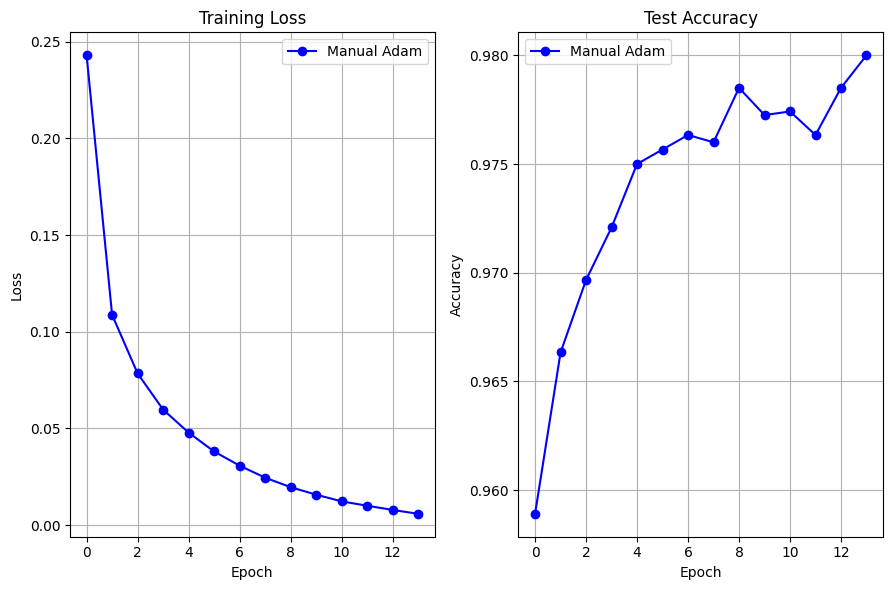

In [12]:
# 可视化比较结果
plt.figure(figsize=(18, 6))

# 训练损失
plt.subplot(1, 4, 1)
plt.plot(manual_adam_losses, label='Manual Adam', marker='o', color='blue')
plt.title('Training Loss')
plt.xlabel('Epoch') 
plt.ylabel('Loss')
plt.legend()
plt.grid(True)


# 测试准确率
plt.subplot(1, 4, 2)
plt.plot(manual_adam_accuracies, label='Manual Adam', marker='o', color='blue')
plt.title('Test Accuracy')
plt.xlabel('Epoch') 
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()



## 实验结果总结

In [13]:
# 输出训练结果
print("手动实现Adam优化模型最终测试准确率: {:.4f}".format(manual_adam_accuracies[-1]))

手动实现Adam优化模型最终测试准确率: 0.9800


通过实验，早停机制被证明在大程度保持训练效果的同时，能够减少训练时间，防止过拟合。